# AI Workforce Intelligence 2030

## Bivariate Analysis

### Objective

This notebook explores relationships between workforce characteristics, AI adoption, automation exposure, employee performance, and future workforce trends. Unlike the exploratory data analysis, which focused on understanding individual variables, this analysis investigates how different business factors interact to generate actionable insights for workforce planning and AI strategy.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

%matplotlib inline

In [2]:
df = pd.read_csv("/content/AI_Impact_on_Jobs_2030.csv")

df.head()

,Employee_ID,Job_Title,Industry,Country,Education_Level,Years_Experience,AI_Replacement_Risk,Future_Demand_Score,Remote_Work_Possibility,Average_Salary_USD,Required_Skills,Automation_Level,Job_Growth_2030,Work_Hours_Per_Week,Company_Size,AI_Tool_Usage,Performance_Score,Upskilling_Needed,Job_Satisfaction,Hiring_Trend_2026
0,AIJ-100000,Data Engineer,Healthcare,Japan,PhD,1,0.25,0.78,Yes,207392,"Python, Communication, Deep Learning",Low,3,37,Enterprise,High,2.08,Yes,3.86,Growing
1,AIJ-100001,Healthcare Analyst,Retail,UK,Bachelor,24,0.73,0.33,No,140785,"Deep Learning, Azure, Communication, TensorFlo...",Low,-5,42,Startup,Moderate,4.54,No,4.23,Growing
2,AIJ-100002,HR Specialist,Education,Canada,High School,21,0.80,0.69,Yes,124800,"Kubernetes, Cloud Computing, TensorFlow, SQL, ...",Medium,-5,57,Startup,Low,3.14,No,3.54,Stable
3,AIJ-100003,Cybersecurity Analyst,Government,UK,Bachelor,5,0.29,0.94,No,199878,"Excel, Kubernetes, Prompt Engineering, Leadership",Medium,7,59,Enterprise,High,3.67,No,4.37,Declining
4,AIJ-100004,Healthcare Analyst,Education,UAE,PhD,20,0.11,0.92,No,178682,"SQL, Leadership, TensorFlow, Cybersecurity",Low,6,34,Startup,High,3.68,No,3.99,Stable


# 4. Correlation Analysis

## Business Question

Which numerical workforce variables exhibit the strongest linear relationships, and which business metrics should be prioritized for deeper investigation during bivariate analysis?

In [3]:
numerical_df = df.select_dtypes(include=["int64", "float64"])

corr_matrix = numerical_df.corr()

corr_matrix

,Years_Experience,AI_Replacement_Risk,Future_Demand_Score,Average_Salary_USD,Job_Growth_2030,Work_Hours_Per_Week,Performance_Score,Job_Satisfaction
Years_Experience,1.000000,-0.033668,-0.047494,0.012795,-0.023781,-0.010387,0.023758,0.018071
AI_Replacement_Risk,-0.033668,1.000000,0.007761,-0.006714,0.004887,0.001582,-0.012806,0.016181
Future_Demand_Score,-0.047494,0.007761,1.000000,0.005162,0.054455,-0.004530,0.018239,0.012901
Average_Salary_USD,0.012795,-0.006714,0.005162,1.000000,-0.011723,-0.012034,-0.009519,0.017736
Job_Growth_2030,-0.023781,0.004887,0.054455,-0.011723,1.000000,0.001496,-0.011879,0.001757
Work_Hours_Per_Week,-0.010387,0.001582,-0.004530,-0.012034,0.001496,1.000000,0.020974,0.014921
Performance_Score,0.023758,-0.012806,0.018239,-0.009519,-0.011879,0.020974,1.000000,-0.013037
Job_Satisfaction,0.018071,0.016181,0.012901,0.017736,0.001757,0.014921,-0.013037,1.000000


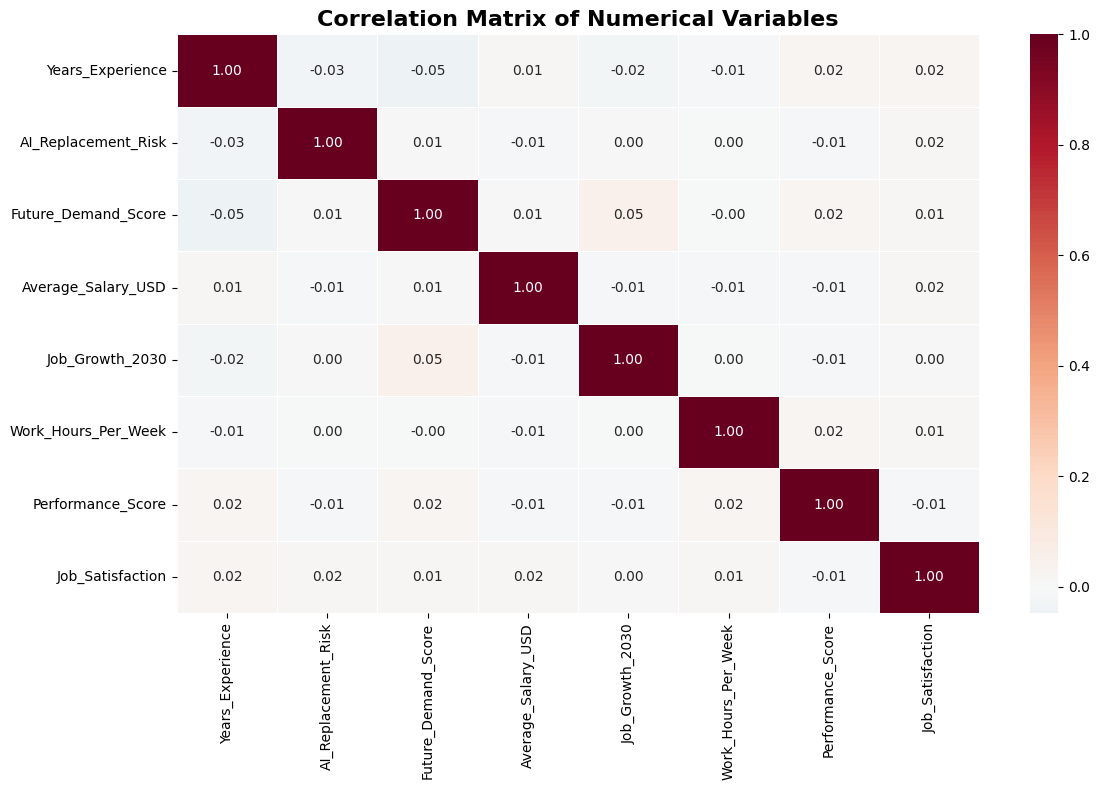

In [4]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
    fmt=".2f"
)

plt.title(
    "Correlation Matrix of Numerical Variables",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

### Observation

The correlation analysis indicates that none of the numerical variables exhibit strong linear relationships. All correlation coefficients are close to zero, suggesting minimal direct linear association between workforce characteristics, AI-related metrics, and employee outcomes within the dataset.

### Business Insight

Since strong linear relationships are not observed, relying solely on correlation analysis may overlook meaningful differences between employee groups. Therefore, subsequent analyses will compare categorical groups and aggregated business metrics to identify patterns that are more relevant for workforce planning and strategic decision-making.

### Executive Recommendation

Organizations should complement correlation analysis with comparative and group-based analyses, as workforce characteristics and AI adoption often exhibit non-linear or categorical relationships that are not captured through Pearson correlation alone.

### Key Takeaway

The absence of strong linear correlations highlights the need for deeper comparative analyses to uncover actionable workforce insights.

## 5. Workforce Experience & Compensation


## 5.1 Experience Group vs Average Salary

### Business Question

How does average salary vary across different levels of professional experience, and what does this indicate about compensation trends within the workforce?

In [5]:
experience_bins = [0, 5, 10, 15, 20, 25]

experience_labels = [
    "0-5 Years",
    "6-10 Years",
    "11-15 Years",
    "16-20 Years",
    "21-25 Years"
]

df["Experience_Group"] = pd.cut(
    df["Years_Experience"],
    bins=experience_bins,
    labels=experience_labels,
    include_lowest=True
)

In [6]:
salary_by_experience = (
    df.groupby("Experience_Group", observed=True)["Average_Salary_USD"]
      .mean()
      .round(2)
      .reset_index()
)

salary_by_experience.columns = [
    "Experience Group",
    "Average Salary (USD)"
]

salary_by_experience

,Experience Group,Average Salary (USD)
0,0-5 Years,126676.56
1,6-10 Years,123912.70
2,11-15 Years,128050.17
3,16-20 Years,126631.92
4,21-25 Years,127845.46


/tmp/ipykernel_694/1660443033.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


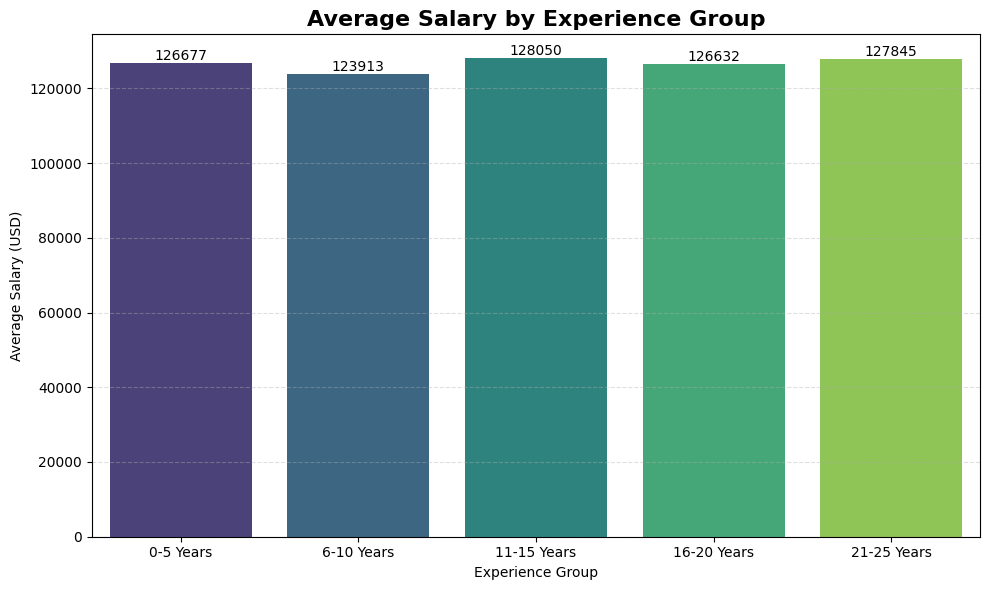

In [7]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=salary_by_experience,
    x="Experience Group",
    y="Average Salary (USD)",
    palette="viridis"
)

plt.title(
    "Average Salary by Experience Group",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Experience Group")
plt.ylabel("Average Salary (USD)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

### Observation

Average salaries remain relatively consistent across all experience groups, ranging from approximately $123,900 to $128,100. No clear upward or downward trend is observed as professional experience increases, indicating that salary differences across experience levels are minimal within the dataset.

### Business Insight

The findings suggest that years of experience alone do not explain salary variations in this workforce. Compensation may instead be influenced by other factors such as job role, industry, specialized skills, company policies, or market demand, which require further investigation.

### Executive Recommendation

Organizations should adopt a multi-factor compensation strategy rather than relying primarily on years of experience. Salary benchmarking should incorporate role complexity, technical expertise, business impact, and critical skill requirements to ensure equitable and competitive compensation.

### Key Takeaway

Professional experience, by itself, does not appear to be a strong determinant of salary within this dataset, highlighting the need to evaluate additional workforce characteristics when analyzing compensation trends.

## 5.2 Automation Level vs AI Replacement Risk

### Business Question

How does AI replacement risk vary across different automation levels, and what implications does this have for workforce planning and AI adoption strategies?

In [8]:
risk_by_automation = (
    df.groupby("Automation_Level", observed=True)["AI_Replacement_Risk"]
      .mean()
      .round(3)
      .reset_index()
)

risk_by_automation.columns = [
    "Automation Level",
    "Average AI Replacement Risk"
]

risk_by_automation

,Automation Level,Average AI Replacement Risk
0,High,0.504
1,Low,0.495
2,Medium,0.510


In [10]:
order = ["Low", "Medium", "High"]

/tmp/ipykernel_694/1234627227.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


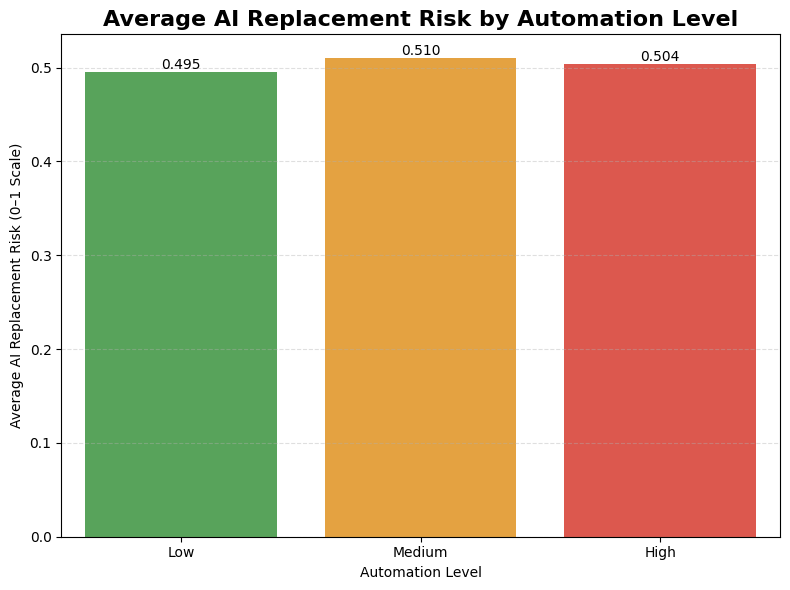

In [12]:
plt.figure(figsize=(8,6))

ax = sns.barplot(
    data=risk_by_automation,
    x="Automation Level",
    y="Average AI Replacement Risk",
    order=order,
    palette=["#4CAF50", "#FFA726", "#F44336"]
)

plt.title(
    "Average AI Replacement Risk by Automation Level",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Automation Level")
plt.ylabel("Average AI Replacement Risk (0–1 Scale)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

### Observation

The average AI replacement risk remains highly consistent across all automation levels, ranging from 0.495 to 0.510. Employees working in low, medium, and high automation environments exhibit nearly identical AI replacement risk scores, indicating no significant variation across automation categories.

### Business Insight

The findings indicate that automation level alone does not significantly influence AI replacement risk within the workforce. This suggests that an employee's likelihood of being impacted by AI is driven by multiple factors, such as job responsibilities, technical skills, AI adoption practices, and organizational strategies, rather than automation exposure alone.

### Executive Recommendation

Organizations should avoid evaluating AI replacement risk solely based on automation levels. Instead, workforce planning should incorporate a comprehensive assessment of employee skills, role criticality, AI adoption maturity, and future business requirements to develop more effective reskilling and workforce transformation strategies.

### Key Takeaway

Automation level, in isolation, is not a reliable predictor of AI replacement risk. Effective workforce transformation requires a holistic evaluation of multiple business and employee-related factors rather than relying on a single operational metric.

## 5.3 AI Tool Usage vs Performance Score

### Business Question

Does the level of AI tool usage influence employee performance, and what insights can organizations derive regarding AI adoption and workforce productivity?

In [13]:
performance_by_ai = (
    df.groupby("AI_Tool_Usage", observed=True)["Performance_Score"]
      .mean()
      .round(2)
      .reset_index()
)

performance_by_ai.columns = [
    "AI Tool Usage",
    "Average Performance Score"
]

performance_by_ai

,AI Tool Usage,Average Performance Score
0,High,3.53
1,Low,3.50
2,Moderate,3.51


/tmp/ipykernel_694/2356207095.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


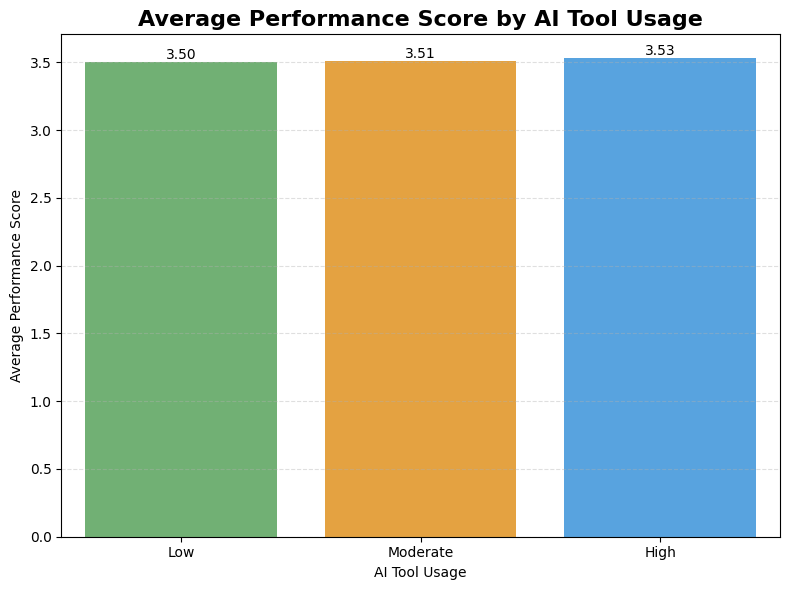

In [14]:
plt.figure(figsize=(8,6))

ax = sns.barplot(
    data=performance_by_ai,
    x="AI Tool Usage",
    y="Average Performance Score",
    order=["Low", "Moderate", "High"],
    palette=["#66BB6A", "#FFA726", "#42A5F5"]
)

plt.title(
    "Average Performance Score by AI Tool Usage",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("AI Tool Usage")
plt.ylabel("Average Performance Score")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

### Observation

Average employee performance remains highly consistent across all AI tool usage levels, ranging from 3.50 to 3.53. The differences between low, moderate, and high AI tool usage groups are minimal, indicating no substantial variation in performance scores based on AI tool adoption.

### Business Insight

The results suggest that AI tool usage alone does not significantly influence employee performance within the dataset. Employee productivity is likely affected by multiple organizational and individual factors, including experience, technical expertise, collaboration, role complexity, and business processes.

### Executive Recommendation

Organizations should avoid measuring the success of AI adoption solely through performance metrics. AI implementation strategies should also consider employee enablement, workflow optimization, skill development, and organizational readiness to maximize long-term business value.

### Key Takeaway

Higher AI tool usage does not necessarily translate into higher employee performance, highlighting the importance of complementary organizational factors when evaluating AI initiatives.

# 6. Executive Summary

This section consolidates the key findings from the bivariate analysis and translates them into strategic business recommendations. Rather than focusing solely on statistical outcomes, the objective is to highlight actionable insights that can support workforce planning, AI adoption strategies, and long-term organizational decision-making.

## 6.1 Key Findings

• Correlation analysis revealed negligible linear relationships among the numerical workforce variables, indicating that no single numerical metric strongly explains workforce outcomes.

• Average salary remained relatively consistent across all experience groups, suggesting that professional experience alone is not the primary driver of employee compensation within the dataset.

• AI replacement risk exhibited minimal variation across different automation levels, highlighting that workforce displacement risk is influenced by multiple organizational and role-specific factors rather than automation exposure alone.

• Employee performance scores remained stable across different AI tool usage levels, indicating that AI adoption alone does not guarantee measurable improvements in workforce productivity.

• Overall, the analyses suggest that workforce intelligence is multidimensional and requires organizations to evaluate multiple business factors simultaneously instead of relying on isolated metrics.

## 6.2 Strategic Recommendations

• Adopt a holistic workforce planning approach that considers employee skills, job roles, business functions, and organizational objectives rather than relying on single-variable indicators.

• Invest in continuous upskilling and reskilling initiatives to prepare employees for evolving AI-driven work environments.

• Evaluate AI implementation success using a balanced set of performance, productivity, employee satisfaction, and business impact metrics.

• Encourage data-driven decision-making by integrating workforce analytics into talent management, compensation planning, and organizational transformation strategies.

## 6.3 Business Conclusion

The bivariate analysis indicates that workforce outcomes cannot be explained through individual variables alone. Across the analyses, employee compensation, AI replacement risk, and performance remained relatively consistent across the evaluated workforce groups, suggesting that organizational outcomes are influenced by multiple interacting factors rather than isolated metrics.

These findings reinforce the importance of adopting a multidimensional workforce analytics approach when designing AI transformation strategies, talent development initiatives, and long-term workforce planning. The results should be interpreted as evidence supporting strategic decision-making within the context of the available workforce data, while highlighting opportunities for deeper multivariate analysis in the next phase of the project.

## 6.4 Limitations of the Analysis

The dataset used in this project exhibits highly balanced distributions and limited linear relationships among key variables. As a result, the findings should be interpreted as exploratory insights rather than evidence of causal relationships. Future analyses using real-world organizational datasets with greater variability may reveal stronger workforce patterns and provide deeper strategic insights.

## 6.5 Next Steps

The next phase of the project will extend the analysis through multivariate techniques to examine how multiple workforce characteristics interact simultaneously. This will provide deeper insights into AI adoption, workforce transformation, employee performance, and future employment trends while supporting more comprehensive business decision-making.